In [1]:
MODEL_CLS = "dae"
NOISE = "04"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{MODEL_CLS}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [4]:
import sys
sys.path.append("src")

# Packages

In [5]:
import pandas as pd
from anomaly.deterministic import config, pipeline, trainer, evaluator, utils
import autoencoder

In [ ]:
cfg = config.builder.config_builder(PATH_CONFIG_FILE)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/creditcard.csv"
origin = pd.read_csv(PATH)

In [9]:
DROP_COL = ["Time", "Amount"]
df = origin.drop(columns=DROP_COL)

In [10]:
Y_COL = "Class"

kwargs = dict(
    df=df,
    y_col=Y_COL,
    cfg=cfg.pipeline,
)

dataloaders = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    noise=float(NOISE)*1e-1,
    **cfg.model.params,
)

model = autoencoder.dae.DenoisedAutoEncoder(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.2009
	BEST EPOCH: 21


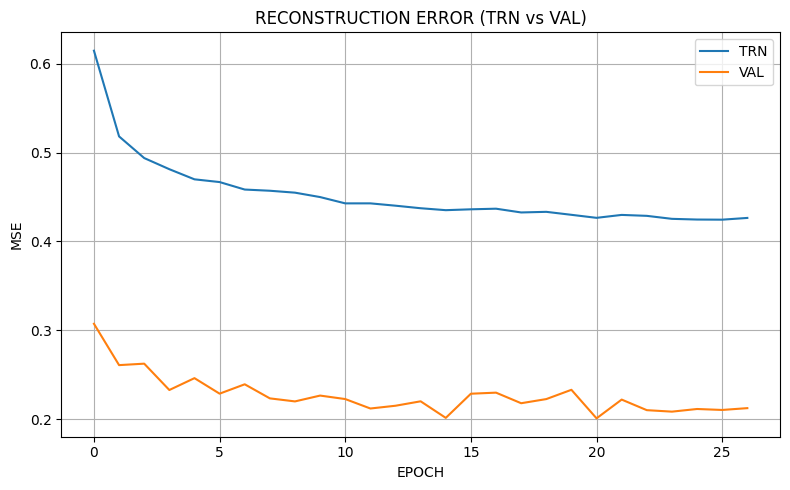

In [14]:
kwargs = dict(
    objs=(records["trn"], records["val"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="MSE",
    title="RECONSTRUCTION ERROR (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

# Evaluation

In [15]:
kwargs = dict(
    model=model,
    scores=records["anomaly"],
    cfg=cfg.evaluator,
)

eval = evaluator.builder.evaluator_builder(**kwargs)

In [16]:
result, metrics_sheet = eval(dataloaders["tst"])

TST: 100%|██████████| 8/8 [00:00<00:00, 1454.02it/s]


In [17]:
metrics_sheet

,p,threshold,tp,tn,fp,fn,accuracy,precision,recall,f1
0,0.950,0.504168,433,475,17,59,0.922764,0.962222,0.880081,0.919321
1,0.955,0.541606,427,477,15,65,0.918699,0.966063,0.867886,0.914347
2,0.960,0.585698,424,480,12,68,0.918699,0.972477,0.861789,0.913793
3,0.965,0.652807,420,482,10,72,0.916667,0.976744,0.853659,0.911063
4,0.970,0.738401,418,483,9,74,0.915650,0.978923,0.849594,0.909684
5,0.975,0.857083,415,487,5,77,0.916667,0.988095,0.843496,0.910088
6,0.980,1.030568,412,487,5,80,0.913618,0.988010,0.837398,0.906491
7,0.985,1.329379,411,488,4,81,0.913618,0.990361,0.835366,0.906284
8,0.990,1.918836,401,490,2,91,0.905488,0.995037,0.815041,0.896089
9,0.995,2.982473,383,491,1,109,0.888211,0.997396,0.778455,0.874429


# Save

In [ ]:
PATH = f'./result/score/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
result.to_csv(**kwargs)

In [ ]:
PATH = f'./result/metric/{cfg.model_cls}_{NOISE}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
metrics_sheet.to_csv(**kwargs)

In [20]:
PATH = f'./checkpoints/{cfg.model_cls}_{NOISE}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)